In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.seyon import SeyonPredictor

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
predictor = SeyonPredictor(k=0.03, draw_rate=0.25)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

# Seyon model

## Algorithm

Seyon predicts match outcomes using the historical relative humidity at each team's capital city on the same calendar date in the prior year (2025).

**Hypothesis:** teams from more humid climates perform better at football.

### Data source

Daily mean relative humidity at 2m above ground, fetched from the [Open-Meteo historical archive API](https://archive-api.open-meteo.com) for June 11–27, 2025 — the same dates as the 2026 group stage, one year prior. Each capital city is represented by its coordinates.

### Prediction formula

For a match on date $D$:

$$\delta = H_{\text{home capital},\,D} - H_{\text{away capital},\,D}$$

$$P(\text{home win}) = \sigma(k \cdot \delta) \times (1 - d), \quad P(\text{draw}) = d, \quad P(\text{away win}) = (1-\sigma(k\cdot\delta)) \times (1-d)$$

| Parameter | Value | Role |
|---|---|---|
| $k$ | 0.03 | Sensitivity of win probability to humidity gap |
| $d$ | 0.25 | Fixed draw rate |

Unlike other models, Seyon's predictions **change by match date** — the same two teams playing on different group-stage days would get different predictions if their capitals' humidity differs across those dates.

### Capital cities

In [2]:
# Show capital cities and their mean humidity over the tournament window
caps = pd.read_csv('../data/capitals.csv')
hum  = pd.read_csv('../data/humidity_2025.csv')

mean_hum = hum.groupby('capital')['humidity'].mean().round(1).reset_index()
mean_hum.columns = ['capital', 'mean_humidity']

caps_with_hum = caps.merge(mean_hum, on='capital')
caps_with_hum['Team'] = caps_with_hum['team'].map(lambda n: f'{flag_map[n]} {n}')
display_caps = caps_with_hum[['Team', 'capital', 'mean_humidity']].sort_values(
    'mean_humidity', ascending=False
).reset_index(drop=True)
display_caps.columns = ['Team', 'Capital', 'Mean humidity % (Jun 2025)']

display_caps.style \
    .hide(axis='index') \
    .background_gradient(subset='Mean humidity % (Jun 2025)', cmap='Blues', vmin=0, vmax=100)

Team,Capital,Mean humidity % (Jun 2025)
🇵🇦 Panama,Panama City,89.000000
🇨🇮 Ivory Coast,Yamoussoukro,87.900000
🇬🇭 Ghana,Accra,86.500000
🇨🇴 Colombia,Bogotá,82.600000
🇦🇺 Australia,Canberra,81.800000
🇲🇽 Mexico,Mexico City,80.900000
🇺🇾 Uruguay,Montevideo,80.400000
🇵🇾 Paraguay,Asunción,80.400000
🇳🇿 New Zealand,Wellington,80.300000
🇪🇨 Ecuador,Quito,78.800000


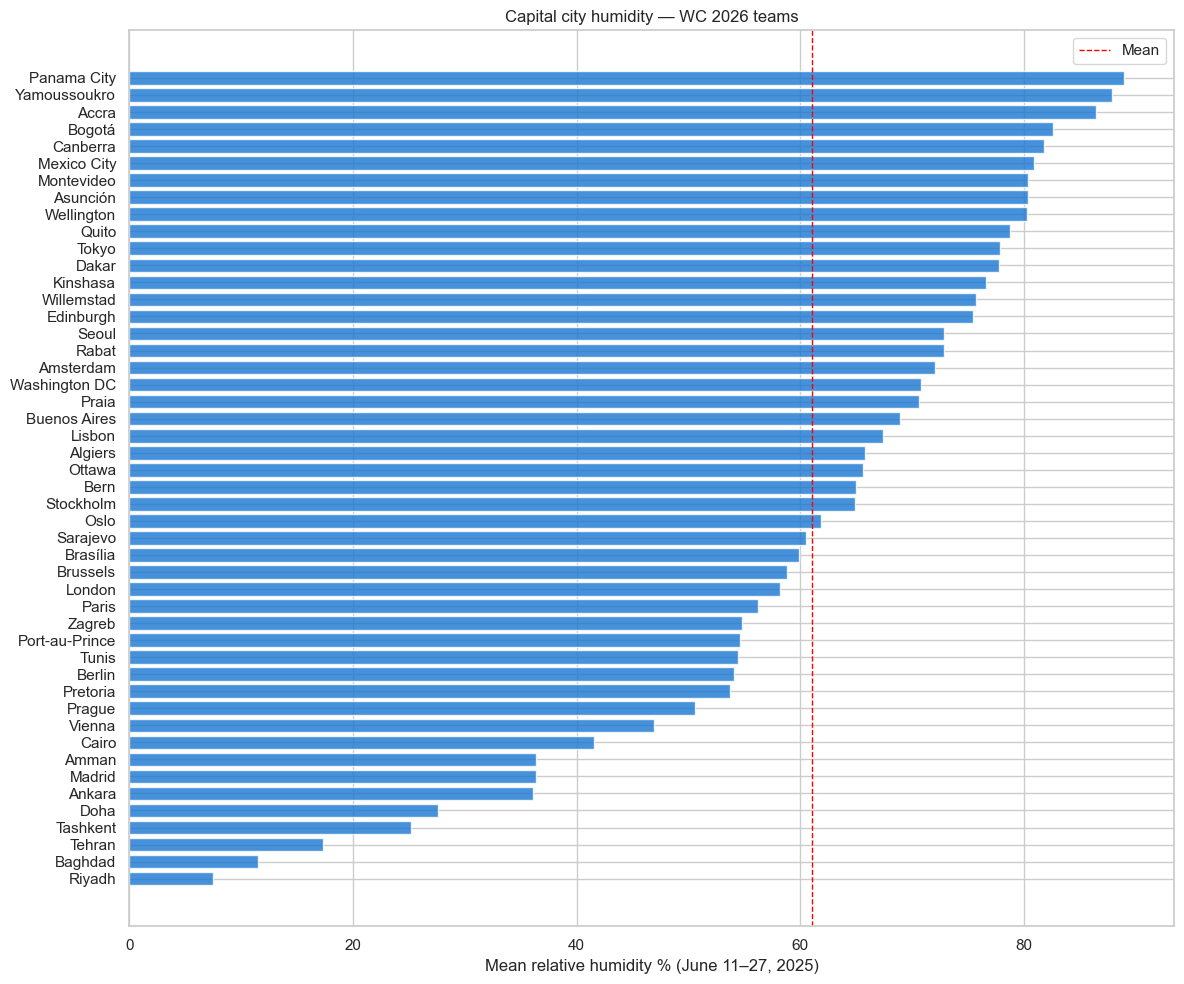

In [3]:
# Bar chart of mean humidity by capital
fig, ax = plt.subplots(figsize=(12, 10))
plot_df = display_caps.sort_values('Mean humidity % (Jun 2025)')
ax.barh(plot_df['Capital'], plot_df['Mean humidity % (Jun 2025)'], color='#1976D2', alpha=0.8)
ax.set_xlabel('Mean relative humidity % (June 11–27, 2025)')
ax.set_title('Capital city humidity — WC 2026 teams', fontsize=12)
ax.axvline(plot_df['Mean humidity % (Jun 2025)'].mean(), color='red',
           linestyle='--', linewidth=1, label='Mean')
ax.legend()
plt.tight_layout()
plt.show()

### Example prediction — France vs Senegal (June 16)

In [4]:
example_home = next(t for t in teams if t.name == 'France')
example_away = next(t for t in teams if t.name == 'Senegal')

match_date = predictor._schedule[frozenset({example_home.name, example_away.name})]
h_hum = predictor._get_humidity(example_home.name, match_date)
a_hum = predictor._get_humidity(example_away.name, match_date)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

print(f'Match date (2026): {match_date.replace("2025", "2026")}  →  humidity lookup: {match_date}')
print(f'{example_home.name} ({predictor._capitals[example_home.name]}): {h_hum:.1f}% humidity')
print(f'{example_away.name} ({predictor._capitals[example_away.name]}):  {a_hum:.1f}% humidity')
print(f'Humidity gap (home − away): {h_hum - a_hum:+.1f}%')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

Match date (2026): 2026-06-16  →  humidity lookup: 2025-06-16
France (Paris): 59.0% humidity
Senegal (Dakar):  78.0% humidity
Humidity gap (home − away): -19.0%


Outcome,Probability
🇫🇷 France win,27.1%
Draw,25.0%
🇸🇳 Senegal win,47.9%


---

## Match predictions

Humidity values and predicted outcome probabilities for all 72 group stage matches.

In [5]:
sched = pd.read_csv('../data/schedule.csv')
match_rows = []
for _, srow in sched.iterrows():
    home_name = str(srow['home'])
    away_name = str(srow['away'])
    home = next(t for t in teams if t.name == home_name)
    away = next(t for t in teams if t.name == away_name)
    match_date = predictor._schedule[frozenset({home_name, away_name})]
    h_hum = predictor._get_humidity(home_name, match_date)
    a_hum = predictor._get_humidity(away_name, match_date)
    p_hw, p_d, p_aw = predictor.predict(home, away)
    match_rows.append({
        'Date':       str(srow['date']),
        'Group':      str(srow['group']),
        'Home':       f'{flag_map[home_name]} {home_name}',
        'Away':       f'{flag_map[away_name]} {away_name}',
        'Home hum %': round(h_hum, 1),
        'Away hum %': round(a_hum, 1),
        'Δ hum':      round(h_hum - a_hum, 1),
        'Home win %': p_hw,
        'Draw %':     p_d,
        'Away win %': p_aw,
    })

matches_df = pd.DataFrame(match_rows)
matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Δ hum',      cmap='RdBu',   vmin=-60, vmax=60)

Date,Group,Home,Away,Home hum %,Away hum %,Δ hum,Home win %,Draw %,Away win %
2026-06-11,A,🇲🇽 Mexico,🇿🇦 South Africa,65.000000,59.000000,6.000000,40.9%,25.0%,34.1%
2026-06-11,A,🇰🇷 South Korea,🇨🇿 Czechia,53.000000,58.000000,-5.000000,34.7%,25.0%,40.3%
2026-06-12,B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,72.000000,66.000000,6.000000,40.9%,25.0%,34.1%
2026-06-12,D,🇺🇸 United States,🇵🇾 Paraguay,58.000000,72.000000,-14.000000,29.7%,25.0%,45.3%
2026-06-13,B,🇶🇦 Qatar,🇨🇭 Switzerland,32.000000,67.000000,-35.000000,19.4%,25.0%,55.6%
2026-06-13,C,🇧🇷 Brazil,🇲🇦 Morocco,70.000000,77.000000,-7.000000,33.6%,25.0%,41.4%
2026-06-13,C,🇭🇹 Haiti,🏴󠁧󠁢󠁳󠁣󠁴󠁿 Scotland,53.000000,69.000000,-16.000000,28.7%,25.0%,46.3%
2026-06-13,D,🇦🇺 Australia,🇹🇷 Türkiye,82.000000,45.000000,37.000000,56.4%,25.0%,18.6%
2026-06-14,E,🇩🇪 Germany,🇨🇼 Curaçao,42.000000,73.000000,-31.000000,21.2%,25.0%,53.8%
2026-06-14,E,🇨🇮 Ivory Coast,🇪🇨 Ecuador,91.000000,87.000000,4.000000,39.7%,25.0%,35.3%


---

## Group stage qualification probabilities

In [6]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']     = df['team'].map(flag_map)
df['group']    = df['team'].map(group_map)
df['Team']     = df['flag'] + ' ' + df['team']
df['capital']  = df['team'].map(predictor._capitals)
df['mean_hum'] = df['capital'].map(predictor._capital_means).round(1)

qual_table = df[['group', 'Team', 'mean_hum', 'p_qualify', 'p_group_winner',
                 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', 'Mean hum %', 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',    cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated', cmap='RdYlGn_r', vmin=0, vmax=1) \
    .background_gradient(subset='Mean hum %', cmap='Blues',    vmin=0, vmax=100)

Group,Team,Mean hum %,Qualify,1st,2nd,Best 3rd,Eliminated
H,🇺🇾 Uruguay,80.400000,89.4%,45.0%,32.3%,12.1%,10.6%
G,🇳🇿 New Zealand,80.300000,88.0%,46.1%,29.0%,12.9%,12.0%
I,🇸🇳 Senegal,77.800000,87.8%,45.4%,29.1%,13.4%,12.2%
K,🇨🇴 Colombia,82.600000,87.1%,42.1%,30.8%,14.2%,12.9%
H,🇨🇻 Cape Verde,70.600000,86.3%,39.1%,33.4%,13.9%,13.7%
K,🇨🇩 Congo DR,76.600000,84.8%,35.8%,33.9%,15.1%,15.2%
J,🇦🇷 Argentina,68.900000,84.6%,43.4%,28.1%,13.1%,15.4%
B,🇨🇦 Canada,65.600000,84.2%,40.7%,28.9%,14.6%,15.8%
L,🇵🇦 Panama,89.000000,83.2%,39.4%,29.1%,14.7%,16.8%
D,🇦🇺 Australia,81.800000,81.6%,37.0%,29.3%,15.2%,18.4%
